# Trabajo de Laboratorio 4: Filtros digitales y FFT

Instalamos numpy y scipy

In [1]:
pip install numpy scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: C:\Users\herra\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

## Ejercicio 2

In [14]:
fs = 10000
fp = 970

# orden
numtaps = 527

# blackman 765
# hamming 545
# hann 800
# bartlett 10000
# boxcar

# ventanas a probar
windows = [
    'boxcar',    # rectangular
    'bartlett',
    'hann',
    'hamming',
    'blackman'
]

win = "hamming"

Ejemplo de filtro con ventana "Hann"

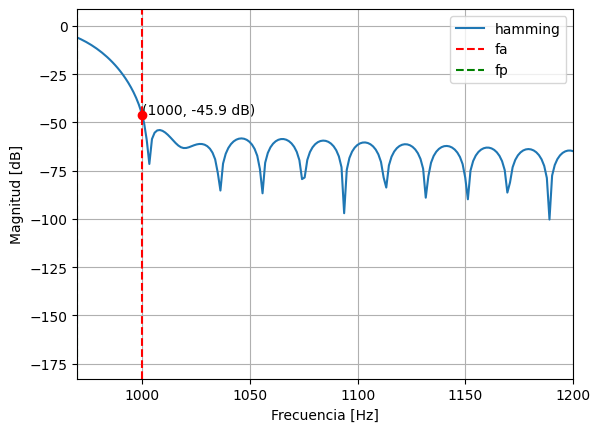

In [15]:
plt.figure()
fs_ds = 2000
fa  = fs_ds / 2

h = signal.firwin(
    numtaps,
    cutoff=fp,
    window=win,
    fs=fs
)


w, H = signal.freqz(h, worN=4096, fs=fs)

H_db = 20*np.log10(np.abs(H) + 1e-12)

plt.plot(w, H_db, label=f"{win}")

y_fa = np.interp(fa, w, H_db)
plt.text(fa, y_fa, f"({fa:.0f}, {y_fa:.1f} dB)")

plt.axvline(fa, linestyle='--', color='red', label='fa')
plt.axvline(fp, linestyle='--', color='green', label='fp')

plt.scatter(fa, y_fa, color='red', zorder=5)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.legend()
plt.xlim(fp, 1.2*fa)
plt.grid()
plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 10000
fp = 970
fa = 1000

windows = ['boxcar', 'bartlett', 'hann', 'hamming', 'blackman']

def cumple_especificacion(numtaps, win):
    h = signal.firwin(numtaps, cutoff=fp, window=win, fs=fs)
    w, H = signal.freqz(h, worN=4096, fs=fs)
    H_db = 20*np.log10(np.abs(H) + 1e-12)
    
    # --- banda de rechazo completa ---
    idx = w >= fa
    H_stop = H_db[idx]
    
    peor_caso = np.max(H_stop)  # peor punto (el más alto en dB)
    
    return peor_caso <= -50, peor_caso

resultados = {}

for win in windows:
    print(f"\nProbando ventana: {win}")
    
    numtaps = 51  # mejor empezar impar
    encontrado = False
    
    while numtaps < 5000:
        ok, peor_caso = cumple_especificacion(numtaps, win)
        
        if ok:
            print(f"✔ Cumple con {numtaps} taps (peor caso ≥1000Hz = {peor_caso:.2f} dB)")
            resultados[win] = numtaps
            encontrado = True
            break
        
        numtaps += 2  # mantener impar
    
    if not encontrado:
        print("❌ No cumple en el rango probado")

print("\nResumen:")
for win, taps in resultados.items():
    print(f"{win}: {taps} taps")


Probando ventana: boxcar
❌ No cumple en el rango probado

Probando ventana: bartlett
❌ No cumple en el rango probado

Probando ventana: hann
✔ Cumple con 761 taps (peor caso ≥1000Hz = -50.10 dB)

Probando ventana: hamming
✔ Cumple con 527 taps (peor caso ≥1000Hz = -50.22 dB)

Probando ventana: blackman
✔ Cumple con 741 taps (peor caso ≥1000Hz = -50.21 dB)

Resumen:
hann: 761 taps
hamming: 527 taps
blackman: 741 taps


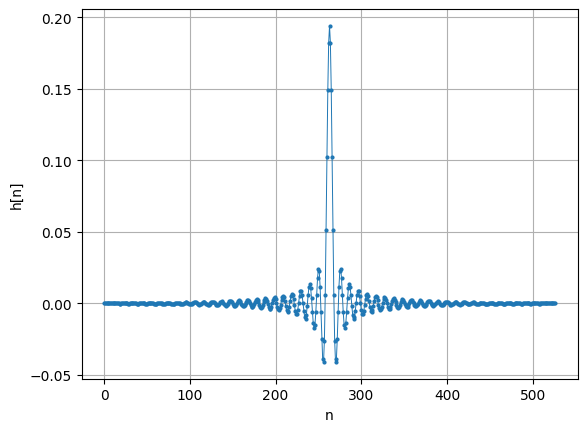

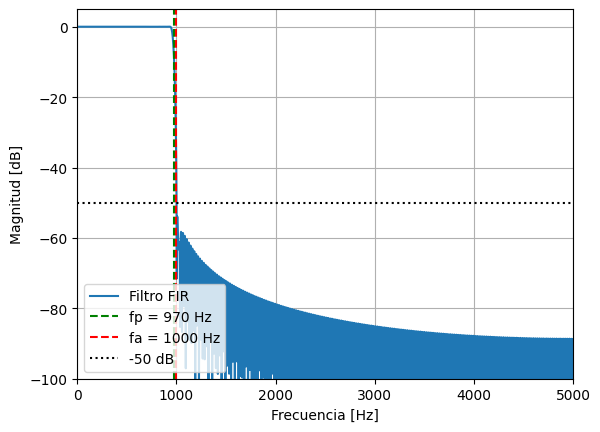

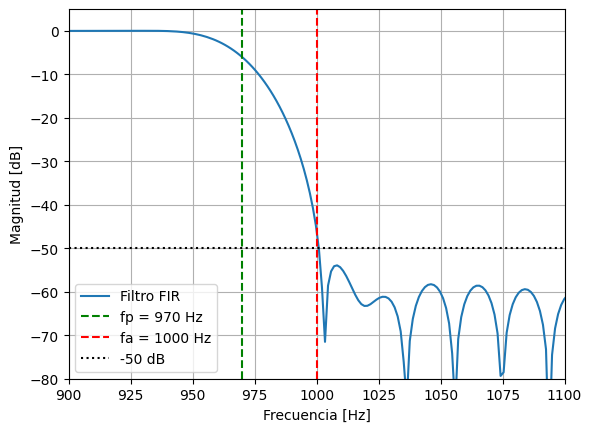

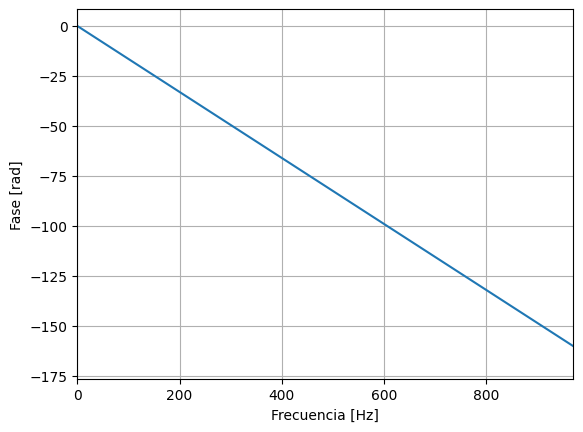

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- parámetros ---
fs = 10000
fp = 970
fa = 1000
numtaps = 527
win = 'hamming'

# --- diseño del filtro ---
h = signal.firwin(numtaps, cutoff=fp, window=win, fs=fs)

# --- respuesta en frecuencia ---
w, H = signal.freqz(h, worN=4096, fs=fs)
H_db = 20*np.log10(np.abs(H) + 1e-12)
H_phase = np.unwrap(np.angle(H))

# --- peor caso en banda de rechazo ---
idx_stop = w >= fa
H_stop = H_db[idx_stop]
w_stop = w[idx_stop]

peor_valor = np.max(H_stop)
peor_freq = w_stop[np.argmax(H_stop)]

# =========================
# 1) RESPUESTA IMPULSIVA
# =========================
plt.figure()
plt.plot(h, marker='o', markersize=2, linewidth=0.7)
plt.xlabel("n")
plt.ylabel("h[n]")
plt.grid()

# =========================
# 2) MAGNITUD COMPLETA
# =========================
plt.figure()
plt.plot(w, H_db, label='Filtro FIR')

plt.axvline(fp, color='green', linestyle='--', label='fp = 970 Hz')
plt.axvline(fa, color='red', linestyle='--', label='fa = 1000 Hz')
plt.axhline(-50, color='black', linestyle=':', label='-50 dB')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.xlim(0, fs/2)
plt.ylim(-100, 5)
plt.legend(loc='lower left')
plt.grid()

# =========================
# 3) ZOOM TRANSICIÓN
# =========================
plt.figure()
plt.plot(w, H_db, label='Filtro FIR')

plt.axvline(fp, color='green', linestyle='--', label='fp = 970 Hz')
plt.axvline(fa, color='red', linestyle='--', label='fa = 1000 Hz')
plt.axhline(-50, color='black', linestyle=':', label='-50 dB')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.xlim(900, 1100)
plt.ylim(-80, 5)
plt.legend(loc='lower left')
plt.grid()

# =========================
# 4) FASE
# =========================
plt.figure()
plt.plot(w, H_phase)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")
plt.xlim(0, fp)
plt.grid()

plt.show()

Señal de entrada de prueba

In [31]:
fs = 10000
f = 600
t = np.arange(0, 10, 1/fs)
x = signal.square(2*np.pi*600*t)

(0.0, 0.06)

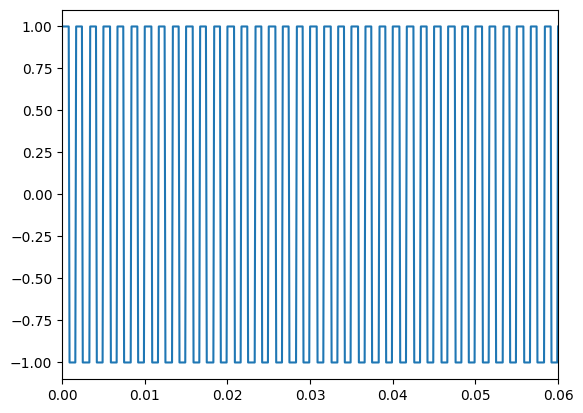

In [30]:
plt.plot(t, x)
plt.xlim(0, 600/fs)

Escriba su función de procesamiento FIR acá

In [39]:
import numpy as np
import time

def fir_filter(x, h):
    x = np.asarray(x)
    h = np.asarray(h)
    
    N = len(h)
    L = len(x)
    
    y = np.zeros(L)
    
    #Debemos realizar la convolución de h y x
    for n in range(L):
        for k in range(N):
            if n-k>=0:
                y[n] += h[k] * x[n-k]

    return y

In [ ]:
# --- filtrado ---
y = fir_filter(x, h)

#--- down-sampling ---
N_ds = 5

y_ds = y[::N_ds]
t_ds = t[::N_ds]

In [75]:
n_runs = 5
tiempos = []

for _ in range(n_runs):
    start = time.perf_counter()
    y = fir_filter(x, h)
    end = time.perf_counter()
    
    tiempos.append(end - start)

t_total = np.mean(tiempos)
t_por_muestra = t_total / len(x)

print(f"Tiempo total promedio: {t_total:.6f} s")
print(f"Tiempo por muestra: {t_por_muestra*1e6:.3f} us")

for i, t in enumerate(tiempos):
    print(f"Corrida {i+1}: {t:.6f} s")

Tiempo total promedio: 18.480776 s
Tiempo por muestra: 184.808 us
Corrida 1: 19.135894 s
Corrida 2: 18.456400 s
Corrida 3: 18.152865 s
Corrida 4: 18.438790 s
Corrida 5: 18.219928 s


In [ ]:
print(tiempos)

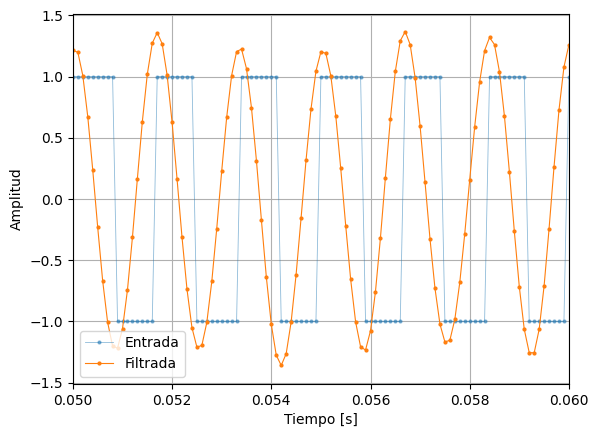

In [49]:
delay = (len(h) - 1) // 2

y_aligned = y[delay:]
t_aligned = t[delay:]

plt.figure()

plt.plot(t_aligned, x[delay:],
         marker='o', markersize=2,
         linewidth=0.6,
         alpha=0.5,
         label='Entrada')

plt.plot(t_aligned, y_aligned,
         marker='o', markersize=2,
         linewidth=0.8,
         label='Filtrada')

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.xlim(0.05, 0.06)
plt.legend()
plt.grid()

plt.show()

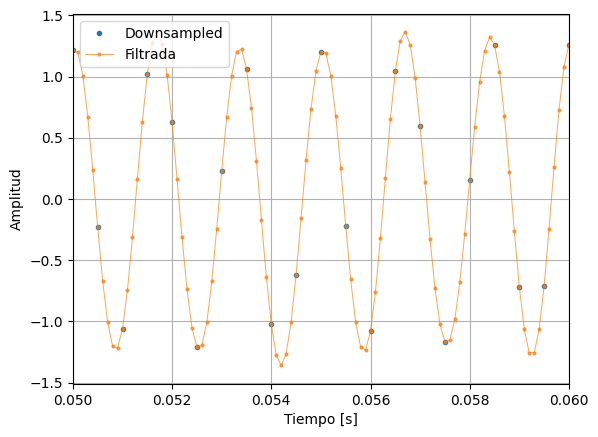

In [56]:
plt.figure()

plt.plot(t_ds, y_ds,
         marker='o', linestyle='none',
         markersize=3,
         label='Downsampled')

plt.plot(t, y,
         marker='o', markersize=2,
         linewidth=0.7,
         alpha=0.7,
         label='Filtrada')



plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.xlim(0.05, 0.06)
plt.legend()
plt.grid()

plt.show()

In [85]:
# --- ventana ---
win = np.hanning(len(x))
x_win = x * win

# --- FFT ---
X = np.fft.fft(x_win)
X = np.abs(X) / len(X)   # normalización

freq = np.fft.fftfreq(len(X), d=1/fs)

# solo frecuencias positivas
idx = freq >= 0
freq = freq[idx]
X = X[idx]

# --- ventana ---
win_y = np.hanning(len(y))
y_win = y * win_y

# --- FFT ---
Y = np.fft.fft(y_win)
Y = np.abs(Y) / len(Y)

freq_y = np.fft.fftfreq(len(Y), d=1/fs)

# solo frecuencias positivas
idx = freq_y >= 0
freq_y = freq_y[idx]
Y = Y[idx]


# --- ventana ---
win_y_ds = np.hanning(len(y_ds))
y_win_ds = y_ds * win_y_ds

# --- FFT ---
Y_ds = np.fft.fft(y_win_ds)
Y_ds = np.abs(Y_ds) / len(Y_ds)

freq_y_ds = np.fft.fftfreq(len(Y_ds), d=1/fs_ds)

# solo frecuencias positivas
idx = freq_y_ds >= 0
freq_y_ds = freq_y_ds[idx]
Y_ds = Y_ds[idx]


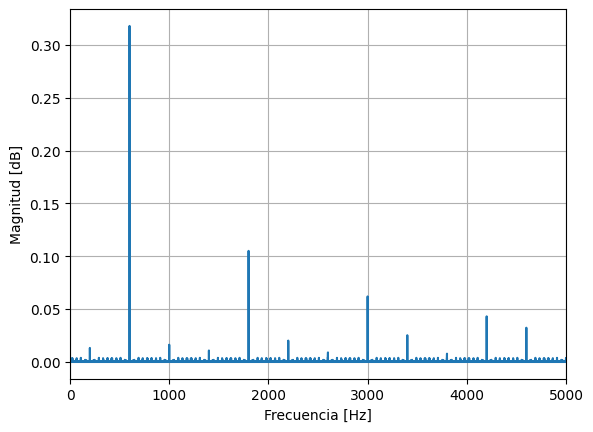

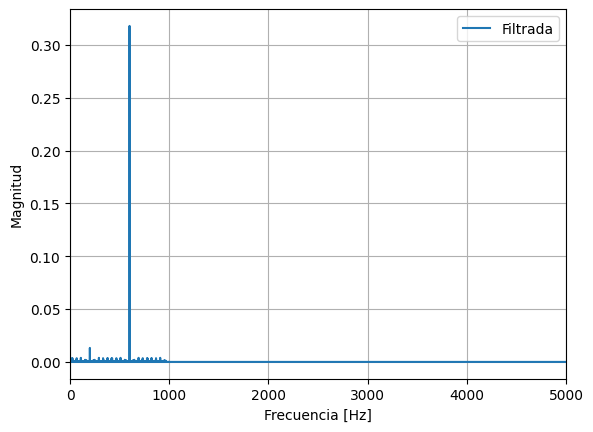

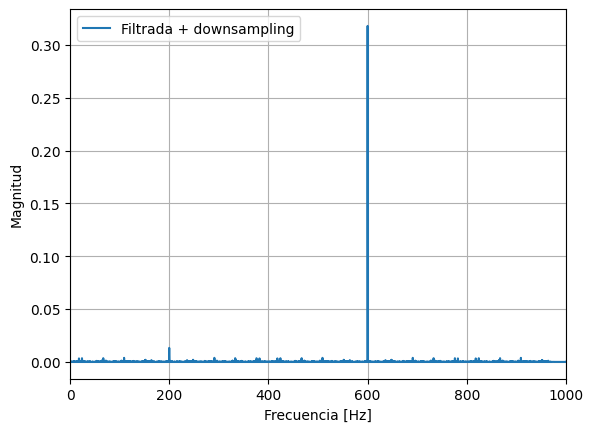

In [87]:
plt.figure()
plt.plot(freq, X)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.xlim(0, 5000)
plt.grid()

plt.show()

plt.figure()
plt.plot(freq_y, Y, label='Filtrada')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, 5000)
plt.legend()
plt.grid()

plt.show()

plt.figure()
plt.plot(freq_y_ds, Y_ds, label='Filtrada + downsampling')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, 1000)
plt.legend()
plt.grid()

plt.show()

## Ejercicio 3: FIR aplicando Overlap and Save

In [129]:
import numpy as np
import time

def overlap_save_fir(x, h, L=1024):
    x = np.asarray(x)
    h = np.asarray(h)
    
    N = len(h)
    K =             # tamaño FFT
    
    # Complete su código acá

    return y

SyntaxError: invalid syntax (3511122254.py, line 9)

In [ ]:
# Overlap-Save
y = overlap_save_fir(x, h, L=1024)

In [ ]:
y_ref = y

In [ ]:
import numpy as np
import time

# --- Datos de entrada (asumiendo que ya existen) ---
# h: tus 527 coeficientes
# x: tu señal de entrada
# y_ref: el resultado de ejercicio 1 (convolución lineal) para comparar

L = 1024
M = len(h)
N = 2048  # Potencia de 2 recomendada para h=527 y L=1024

# 1. Pre-cálculo: FFT del filtro (solo una vez)
H = np.fft.fft(h, n=N)

# Inicialización
salida_final = []
tiempos_bloque = []
pasado = np.zeros(M - 1) # M-1 ceros iniciales

# 2. Procesamiento por bloques
for i in range(0, len(x), L):
    start_time = time.perf_counter()
    
    # Tomamos el bloque actual de la señal
    bloque_actual = x[i : i + L]
    
    # Si el último bloque es más chico que L, lo rellenamos con ceros
    if len(bloque_actual) < L:
        bloque_actual = np.pad(bloque_actual, (0, L - len(bloque_actual)))
    
    # Armado del bloque de entrada N=2048: [pasado(526) + actual(1024) + ceros(498)]
    # Usamos np.concatenate o simplemente pasamos el tamaño a np.fft.fft
    entrada_fft = np.concatenate([pasado, bloque_actual])
    
    # Procesamiento espectral
    X = np.fft.fft(entrada_fft, n=N)
    Y = X * H
    y_bloque = np.fft.ifft(Y).real # Nos quedamos con la parte real
    
    # --- OVERLAP AND SAVE: Salvar desde el índice M-1 hasta (M-1 + L) ---
    # Esto extrae exactamente las 1024 muestras limpias
    bloque_limpio = y_bloque[M-1 : M-1+L]
    salida_final.extend(bloque_limpio)
    
    # Actualizamos el pasado para la siguiente iteración
    pasado = bloque_actual[-(M-1):]
    
    end_time = time.perf_counter()
    tiempos_bloque.append(end_time - start_time)

# 3. Mediciones y Comparación
salida_final = np.array(salida_final[:len(x)]) # Recortamos al largo original si es necesario
tiempo_total = sum(tiempos_bloque)
tiempo_por_muestra = tiempo_total / len(x)

print(f"Tiempo total: {tiempo_total:.4f} s")
print(f"Tiempo por muestra: {tiempo_por_muestra:.8f} s")

# Comparación con el ejercicio 1 (y_ref)
# Nota: y_ref debe ser recortado o comparado hasta len(x)
error = np.linalg.norm(salida_final - y_ref[:len(x)])
print(f"Error acumulado contra convolución: {error}")

Tiempo total: 0.0380 s
Tiempo por muestra: 0.00000038 s
Error acumulado contra convolución: 2.2228203505445087e-13
